# Homework 5, Part 2: Answer questions with pandas

**Use the Excel file to answer the following questions.** This is a little more typical of what your data exploration will look like with pandas.

> Again, **don't use ChatGPT for this assignment.** You should be able to memorize the most basic parts of pandas.

## 0) Setup

Import pandas **with the correct name** .

In [2]:
import pandas as pd

## 1) Reading in an Excel file

Use pandas to read in the `richpeople.xlsx` Excel file, saving it as a variable with the name we'll always use for a dataframe.

> **TIP:** You will use `read_excel` instead of `read_csv`. Trying `read_excel` the first time will probably not work, you'll get an error message. Be sure to read the error carefully: *you probably need to install a new library before it will work, and the error tells you what the library is named*. You *might* need to do `Kernel > Restart Kernel...` and run the notebook again from the top in order to get it to work.

In [4]:
%pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [5]:
df = pd.read_excel("richpeople.xlsx")

## 2) Checking your data

Display the number of rows and columns in your data. Also display the names and data types of each column.

In [7]:
print("rowns & Columns:", df.shape)
print("-" * 30)

rowns & Columns: (1653, 30)
------------------------------


In [8]:
print(df.dtypes)

year                         int64
name                           str
rank                         int64
citizenship                    str
countrycode                    str
networthusbillion          float64
selfmade                       str
typeofwealth                   str
gender                         str
age                        float64
industry                    object
IndustryAggregates          object
region                         str
north                        int64
politicalconnection        float64
founder                      int64
generationofinheritance     object
sector                         str
company                        str
companytype                    str
relationshiptocompany          str
foundingdate               float64
gdpcurrentus               float64
sourceofwealth                 str
notes                          str
notes2                         str
source                         str
source_2                       str
source_3            

## 3) Who are the top 10 richest billionaires? Use the `networthusbillion` column.

In [9]:
df.head(10)

,year,name,rank,citizenship,countrycode,networthusbillion,selfmade,typeofwealth,gender,age,...,relationshiptocompany,foundingdate,gdpcurrentus,sourceofwealth,notes,notes2,source,source_2,source_3,source_4
0,2014,A. Jerrold Perenchio,663,United States,USA,2.6,self-made,executive,male,83.0,...,former chairman and CEO,1955.0,NaN,"television, Univision",represented Marlon Brando and Elizabeth Taylor,NaN,http://en.wikipedia.org/wiki/Jerry_Perenchio,http://www.forbes.com/profile/a-jerrold-perenc...,COLUMN ONE; A Hollywood Player Who Owns the Ga...,NaN
1,2014,Abdulla Al Futtaim,687,United Arab Emirates,ARE,2.5,inherited,inherited,male,NaN,...,relation,1930.0,NaN,"auto dealers, investments",company split between him and cousin in 2000,NaN,http://en.wikipedia.org/wiki/Al-Futtaim_Group,http://www.al-futtaim.ae/content/groupProfile.asp,NaN,NaN
2,2014,Abdulla bin Ahmad Al Ghurair,305,United Arab Emirates,ARE,4.8,inherited,inherited,male,NaN,...,relation,1960.0,NaN,diversified,inherited from father,NaN,http://en.wikipedia.org/wiki/Al-Ghurair_Group,http://www.alghurair.com/about-us/our-history,NaN,NaN
3,2014,Abdullah Al Rajhi,731,Saudi Arabia,SAU,2.4,self-made,self-made finance,male,NaN,...,founder,1957.0,NaN,banking,NaN,NaN,http://en.wikipedia.org/wiki/Al-Rajhi_Bank,http://www.alrajhibank.com.sa/ar/investor-rela...,http://www.alrajhibank.com.sa/ar/about-us/page...,NaN
4,2014,Abdulsamad Rabiu,1372,Nigeria,NGA,1.2,self-made,founder non-finance,male,54.0,...,founder,1988.0,NaN,"sugar, flour, cement",NaN,NaN,http://www.forbes.com/profile/abdulsamad-rabiu/,http://www.bloomberg.com/research/stocks/priva...,NaN,NaN
5,2014,Abigail Johnson,50,United States,USA,17.3,inherited,inherited,female,52.0,...,relation,1946.0,NaN,money management,3rd generation,no male siblings,"http://en.wikipedia.org/wiki/Edward_Johnson,_III",https://www.fidelity.com/about-fidelity/our-he...,NaN,NaN
6,2014,Abilio dos Santos Diniz,609,Brazil,BRA,2.8,inherited,inherited,male,77.0,...,relation,1948.0,NaN,retail,"kidnapped for 6 days in 1989, inherited from f...",NaN,http://en.wikipedia.org/wiki/Ab%C3%ADlio_Diniz,http://www.forbes.com/profile/abilio-dos-santo...,NaN,NaN
7,2014,Achmad Hamami,1092,Indonesia,IDN,1.6,self-made,founder non-finance,male,83.0,...,founder,1980.0,NaN,heavy equipment,NaN,NaN,http://www.forbes.com/profile/achmad-hamami/,http://www.trakindo.co.id/website/pages/compan...,NaN,NaN
8,2014,Adi Godrej,446,India,IND,3.5,inherited,inherited,male,71.0,...,relation,1897.0,NaN,consumer goods,3rd generation,NaN,http://en.wikipedia.org/wiki/Godrej_family,http://www.forbes.com/profile/godrej/,NaN,NaN
9,2014,Aerin Lauder Zinterhofer,1465,United States,USA,1.1,inherited,inherited,female,44.0,...,relation,1946.0,NaN,"inherited, cosmetics",3rd generation,NaN,http://en.wikipedia.org/wiki/Jane_Lauder,http://investing.businessweek.com/research/sto...,NaN,NaN


## 4a) How many male billionaires are there compared to the number of female billionares?

> **TIP:** This is not a `.groupby`

In [10]:
df['gender'].value_counts()

gender
male      1473
female     180
Name: count, dtype: int64

## 4b) What percent is that?

> **TIP:** Doing percentages with the answer to `4a` is so common that there's an extra parameter to automatically calculate it. Look at the documentation!

In [11]:
df['gender'].value_counts(normalize=True)


gender
male      0.891107
female    0.108893
Name: proportion, dtype: float64

## 4c) Is the average wealth different for a female billionaire as compared to a male billionaire?

> **TIP:** This one *does* use `.groupby`. You can pick what 'average' means in this context.

In [13]:
df.groupby('gender')['networthusbillion'].mean()

gender
female    3.920556
male      3.902716
Name: networthusbillion, dtype: float64

## 5a) What is the most common source/type of wealth?

In [14]:
df.groupby('gender')['sourceofwealth'].value_counts(normalize=True)  

gender  sourceofwealth                 
female  diversified                        0.052326
        real estate                        0.040698
        media                              0.034884
        consumer goods                     0.029070
        hotels, investments                0.029070
                                             ...   
male    real estate, shipping              0.000684
        Steel                              0.000684
        iron ore, steel, telecoms          0.000684
        copper processing & real estate    0.000684
        TV broadcasting                    0.000684
Name: proportion, Length: 677, dtype: float64

## 5b) Is the most common source/type of wealth different between men and women?

> **TIP:** You know how to `groupby` and you know how to count how many times a value is in a column. Can you put them together??? You could also do this as two separate cells where you calculate it separately for men and women.
>
> **TIP:** Use percentages for this, it makes it a lot more readable.

In [15]:
df['sourceofwealth'].value_counts().head(1)

sourceofwealth
real estate    107
Name: count, dtype: int64

## 6a) What companies have the most billionaires? Let's see the top five.

> **TIP:** You can use `.head()` on *anything*, not just your basic `df`
>
> **TIP:** You might feel like you should use `groupby`, but don't! There's an easier way to count.

In [16]:
df['company'].value_counts().head(5)

company
Hyatt                  11
Oetker-Gruppe           8
S. C. Johnson & Son     7
Alfa Group              6
Walmart                 6
Name: count, dtype: int64

### 6b) Graph those top 5 as a horizontal bar graph. Make the largest bar be at the top of the graph.

> **TIP:** Just try to throw `.plot()` on the end??
> 
> **TIP:** Make the largest bar be at the top of the graph
>
> **TIP:** If your chart seems... weird, think about where in the process you're sorting vs using `head`

<Axes: ylabel='company'>

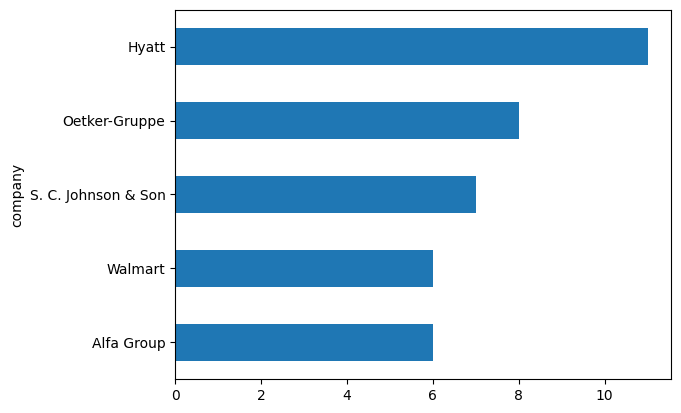

In [17]:
df['company'].value_counts().head(5).sort_values(ascending=True).plot(kind='barh')

## 7) How much money do these top 5 billionaires have in total?

> **TIP:** for multiple conditions, you can't use `or` and `and`. In pandas, `|` means *or* and `&` means *and*.
>
> **TIP:** Checking multiple conditions can be done two ways.
> - `(df.colname == 'A') | (df.colname == 'B')`
> - `df.colname.isin(['A', 'B'])`

In [20]:
top_5_names = df.sort_values(by='networthusbillion', ascending=False).head(5)['name']
df[df['name'].isin(top_5_names)]['networthusbillion'].sum()

np.float64(318.2)

## 8) What are the top 10 countries with the most money held by billionaires?

I am **not** asking which country has the most billionaires - this is **total amount of money per country.**

> **TIP:** Think about it in steps - "I want them organized by country," "I want their net worth," "I want to add it all up," and "I want 10 of them." Just chain it all together.

In [21]:
df.groupby('citizenship')['networthusbillion'].sum().sort_values(ascending=False).head(10)

citizenship
United States     2322.4
Russia             422.5
Germany            401.4
China              375.8
France             235.3
Hong Kong          213.7
Brazil             192.2
India              191.9
Italy              158.1
United Kingdom     152.0
Name: networthusbillion, dtype: float64

## 9a) How old is an average billionaire?

In [22]:
df['age'].mean()

np.float64(63.34213836477988)

## 9b) How old are self-made billionaires compared to non self-made billionaires? 

In [23]:
df.groupby('selfmade')['age'].mean()

selfmade
inherited    64.962185
self-made    62.625899
Name: age, dtype: float64

## 10a) Who are the three youngest billionaires? Who are the three oldest?

In [24]:
print("--- Three Youngest Billionaires ---")
display(df.sort_values(by='age', ascending=True).head(3)[['name', 'age']])
print("\n--- Three Oldest Billionaires ---")
display(df.sort_values(by='age', ascending=False).head(3)[['name', 'age']])

--- Three Youngest Billionaires ---


,name,age
1172,Perenna Kei,24.0
397,Dustin Moskovitz,29.0
1004,Mark Zuckerberg,29.0



--- Three Oldest Billionaires ---


,name,age
343,"David Rockefeller, Sr.",98.0
816,Karl Wlaschek,96.0
836,Kirk Kerkorian,96.0


## 10b) Make a graph of the distribution of ages.

> **TIP:** You use `.plot()` to graph values in a column independently, but `.hist()` to draw a [histogram](https://www.mathsisfun.com/data/histograms.html) of the distribution of their values

<Axes: title={'center': 'Age Distribution of Billionaires'}, ylabel='Frequency'>

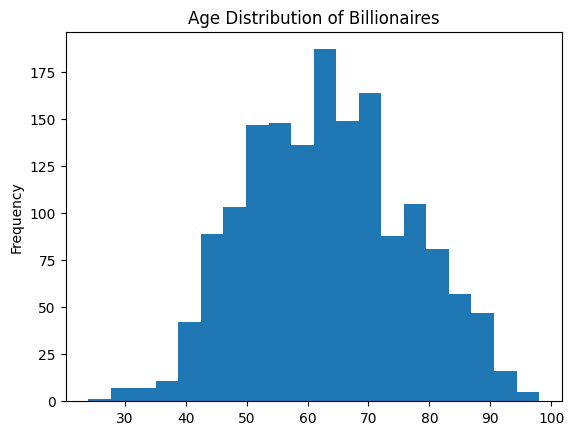

In [25]:
df['age'].plot(kind='hist', bins=20, title="Age Distribution of Billionaires")

## 11) Make a scatterplot of net worth compared to age

It's more fun to do this in Altair as compared to matplotlib, but either is fine.

<Axes: title={'center': 'Net Worth vs Age'}, xlabel='age', ylabel='networthusbillion'>

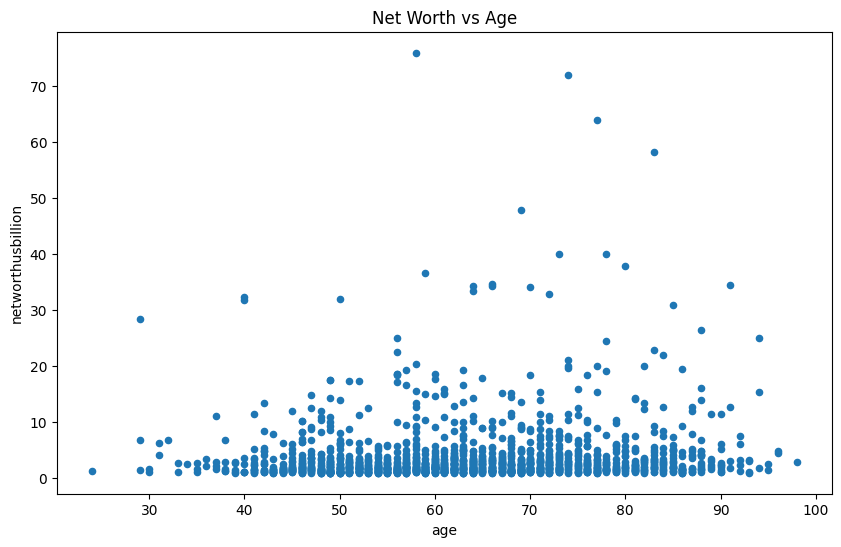

In [26]:
df.plot(kind='scatter', x='age', y='networthusbillion', title="Net Worth vs Age", figsize=(10, 6))

## 13) Make a bar graph of the wealth of the top 10 richest billionaires

> **TIP:** When you make your plot, you'll need to set the `x` and `y` or else your chart will look _crazy_
>
> **TIP:** x and y might be the opposite of what you expect them to be

<Axes: xlabel='name'>

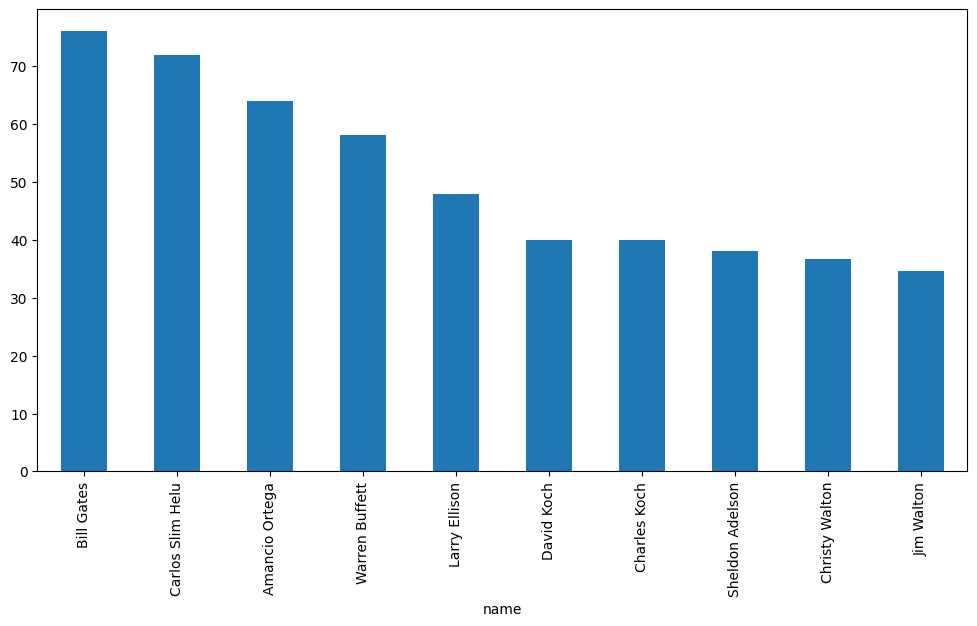

In [27]:
df.sort_values(by='networthusbillion', ascending=False).head(10).set_index('name')['networthusbillion'].plot(kind='bar', figsize=(12, 6))

## 14) Read in the most recent data

I copied and pasted the most recent data from [the original Bloomberg story](https://www.bloomberg.com/billionaires/) (it's in the page's source code), but it all was saved as JSON. Can you use pandas to read in `billionaires.json`?

> **TIP:** If `pd.read_csv` reads a CSV and `pd.read_excel` reads an excel file... what reads in JSON?
>
> **TIP:** It's a lot less complicated than what we did in class.

In [28]:
recent_df = pd.read_json("billionaires.json")

In [29]:
recent_df.head()

,commonName,commonLastName,citizenship,slug,industry,personId,rank,worth,lastChange,lastPercentChange,ytdChange,ytdPercentChange,sector,fWorth,fLastChange,fYtdChange,fLastPercentChange,fYtdPercentChange
0,Elon Musk,Musk,United States,elon-r-musk,Technology,1954518,1,221116780866,9795811154,4.64,84106712938,61.39,Technology,$221B,+$9.80B,+$84.1B,+4.6%,+61.4%
1,Bernard Arnault,Arnault,France,bernard-j-arnault,Consumer,1392853,2,170267873036,7356040557,4.52,8178459368,5.05,Consumer,$170B,+$7.36B,+$8.18B,+4.5%,+5.0%
2,Jeff Bezos,Bezos,United States,jeffrey-p-bezos,Technology,1642252,3,169556171871,3202661603,1.93,62599942079,58.53,Technology,$170B,+$3.20B,+$62.6B,+1.9%,+58.5%
3,Bill Gates,Gates,United States,william-h-gates,Technology,1390479,4,131137012631,1103482475,0.85,21900118029,20.05,Technology,$131B,+$1.10B,+$21.9B,+0.8%,+20.1%
4,Larry Ellison,Ellison,United States,lawrence-j-ellison,Technology,1491757,5,129608081535,2286642464,1.80,37780140594,41.14,Technology,$130B,+$2.29B,+$37.8B,+1.8%,+41.1%
